In [2]:
import numpy as np
import scipy.stats as sts
import scipy.special as sc
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.stats.weightstats
import statsmodels.stats.proportion
%matplotlib inline

In [5]:
import scipy.stats as stats
# Задание 1
# Параметры
m = 5
sigma = 2
n = 50
n_samp = 100
B = 1000
conf = 0.95

# Генерация выборок
samps = np.random.normal(loc=m, scale=sigma, size=(n_samp, n))

# Результаты покрытия (a, b, c, d)
a = []
b = []
c = []
d = []

for samp in samps:
    # Традиционный метод для E
    sm = np.mean(samp)
    ss = np.std(samp, ddof=1)
    tc = stats.t.ppf(1 - (1 - conf)/2, df=n-1)
    mar = tc * ss / np.sqrt(n)
    clt_m = sm - mar
    cht_m = sm + mar
    a.append(1 if clt_m <= m <= cht_m else 0)

    # Традиционный метод для Var
    sv = np.var(samp, ddof=1)
    c2l = stats.chi2.ppf((1 - conf)/2, df=n-1)
    c2h = stats.chi2.ppf(1 - (1 - conf)/2, df=n-1)
    clt_v = (n-1)*sv / c2h
    cht_v = (n-1)*sv / c2l
    tv = sigma**2
    b.append(1 if clt_v <= tv <= cht_v else 0)

    # Бутстреп для E
    bm = [np.mean(np.random.choice(samp, n, True)) for _ in range(B)]
    clb_m = np.percentile(bm, (1 - conf)/2 * 100)
    chb_m = np.percentile(bm, (1 - (1 - conf)/2) * 100)
    c.append(1 if clb_m <= m <= chb_m else 0)

    # Бутстреп для Var
    bv = [np.var(np.random.choice(samp, n, True), ddof=1) for _ in range(B)]
    clb_v = np.percentile(bv, (1 - conf)/2 * 100)
    chb_v = np.percentile(bv, (1 - (1 - conf)/2) * 100)
    d.append(1 if clb_v <= tv <= chb_v else 0)

# Среднее покрытие
a_mean = np.mean(a)
b_mean = np.mean(b)
c_mean = np.mean(c)
d_mean = np.mean(d)

print(f"Традиц.: E {a_mean:.2f}, Var {b_mean:.2f}")
print(f"Бутстреп: E {c_mean:.2f}, Var {d_mean:.2f}")
# Покрытие традиционным методом сработало лучше, это может быть аргументом в пользу того что он подходит больше для нормально распределенной случайной величины в случае если закон распределения известен.

Традиц.: E 0.93, Var 0.95
Бутстреп: E 0.93, Var 0.89


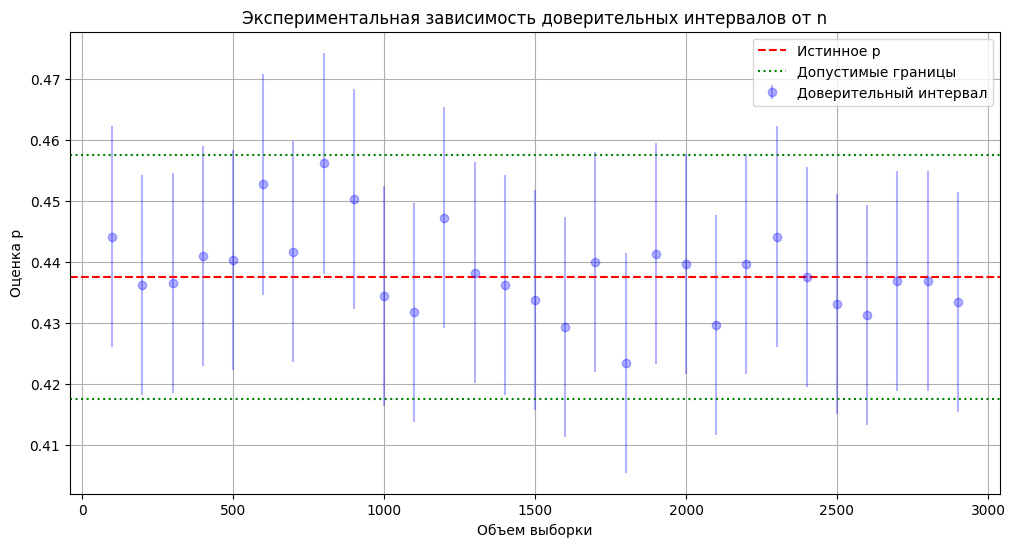

Экспериментальный минимальный n: 2400
Теоретический минимальный n: 2364
Результат функции samplesize_confint_proportion: 2364


In [8]:
from statsmodels.stats.proportion import samplesize_confint_proportion
from scipy.stats import norm, binom
# Задание 2
# Параметры
p = 0.4375
beta = 0.95
epsilon = 0.02  # Точность 2%
alpha = 1 - beta

# 1. Экспериментальная оценка
np.random.seed(42)
n_values = np.arange(100, 3000, 100)  # Диапазон объемов выборки
coverage = []
widths = []

for n in n_values:
    lower = []
    upper = []
    for _ in range(100):  # 100 экспериментов для каждого n
        sample = np.random.binomial(1, p, n)
        p_hat = np.mean(sample)
        z = norm.ppf(1 - alpha/2)
        margin = z * np.sqrt(p_hat*(1 - p_hat)/n)
        lower.append(p_hat - margin)
        upper.append(p_hat + margin)

    # Проверка покрытия и ширины
    lower = np.array(lower)
    upper = np.array(upper)
    coverage.append(np.mean((lower <= p) & (upper >= p)))
    widths.append(np.mean(upper - lower))

# Нахождение минимального n, где ширина <= 2*epsilon
wid = np.array(widths) <= 2*epsilon
if np.any(wid):
    min_n_exp = n_values[np.argmax(wid)]
else:
    min_n_exp = np.nan

# 2. Теоретическая оценка
z = norm.ppf(1 - alpha/2)
n_theory = (z**2 * p * (1 - p)) / (epsilon**2)
n_theory = np.ceil(n_theory).astype(int)

# 3. Использование готовой функции
n_func = samplesize_confint_proportion(p, epsilon, alpha=alpha, method='normal')
n_func = np.ceil(n_func).astype(int)

# Визуализация
plt.figure(figsize=(12, 6))
for i, n in enumerate(n_values):
    plt.errorbar(n, (lower[i] + upper[i])/2, yerr=(upper[i]-lower[i])/2,
                 fmt='o', color='blue', alpha=0.3, label='Доверительный интервал' if i ==0 else "")
plt.axhline(p, color='r', linestyle='--', label='Истинное p')
plt.axhline(p + epsilon, color='g', linestyle=':', label='Допустимые границы')
plt.axhline(p - epsilon, color='g', linestyle=':')
plt.xlabel('Объем выборки')
plt.ylabel('Оценка p')
plt.title('Экспериментальная зависимость доверительных интервалов от n')
plt.legend()
plt.grid(True)
plt.show()

print(f"Экспериментальный минимальный n: {min_n_exp}")
print(f"Теоретический минимальный n: {n_theory}")
print(f"Результат функции samplesize_confint_proportion: {n_func}")